In [21]:
#Importing Libraries
import pandas as pd
!pip install datasets
from datasets import load_dataset

import matplotlib.pyplot as plt

In [22]:
#Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

In [23]:
#Data Cleaning
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])

In [25]:
import pandas as pd

df_jobs = pd.DataFrame({
    "job_id": [1, 2, 3, 4, 5],
    "job_title": [
        "Data Scientist",
        "Software Engineer",
        "Product Manager",
        "Marketing Director",
        "HR Manager"
    ],
    "company_name": [
        "Google",
        "Microsoft",
        "Apple",
        "Nike",
        "Starbucks"
    ],
    "job_location": [
        "Mountain View, CA",
        "Redmond, WA",
        "Cupertino, CA",
        "Beaverton, OR",
        "Seattle, WA"
    ]
})

df_companies = pd.DataFrame({
    "company_name": [
        "Google",
        "Microsoft",
        "Apple",
        "Nike",
        "Starbucks"
    ],
    "industry": [
        "Technology",
        "Technology",
        "Technology",
        "Apparel",
        "Food & Beverage"
    ],
    "company_size": [
        "100,000+",
        "100,000+",
        "100,000+",
        "75,000+",
        "346,000+"
    ]
})

In [26]:
df_jobs

,job_id,job_title,company_name,job_location
0,1,Data Scientist,Google,"Mountain View, CA"
1,2,Software Engineer,Microsoft,"Redmond, WA"
2,3,Product Manager,Apple,"Cupertino, CA"
3,4,Marketing Director,Nike,"Beaverton, OR"
4,5,HR Manager,Starbucks,"Seattle, WA"


In [27]:
df_companies

,company_name,industry,company_size
0,Google,Technology,"100,000+"
1,Microsoft,Technology,"100,000+"
2,Apple,Technology,"100,000+"
3,Nike,Apparel,"75,000+"
4,Starbucks,Food & Beverage,"346,000+"


In [29]:
df_jobs.merge(df_companies, on='company_name')

,job_id,job_title,company_name,job_location,industry,company_size
0,1,Data Scientist,Google,"Mountain View, CA",Technology,"100,000+"
1,2,Software Engineer,Microsoft,"Redmond, WA",Technology,"100,000+"
2,3,Product Manager,Apple,"Cupertino, CA",Technology,"100,000+"
3,4,Marketing Director,Nike,"Beaverton, OR",Apparel,"75,000+"
4,5,HR Manager,Starbucks,"Seattle, WA",Food & Beverage,"346,000+"


In [30]:
df_us_pivot = pd.DataFrame({
    "Business Analyst": [527, 447, 438, 565, 279, 446, 581, 903, 897, 932, 719, 648],
    "Cloud Engineer": [36, 24, 19, 40, 20, 32, 39, 39, 50, 48, 36, 40],
    "Data Analyst": [8494, 6124, 6218, 6049, 4993, 5683, 5201, 6634, 4639, 5271, 4531, 3979],
    "Data Engineer": [2655, 3060, 3183, 2801, 2976, 2893, 2570, 3269, 3224, 3015, 2793, 2641],
    "Data Scientist": [6915, 4956, 4779, 4867, 4377, 4645, 4876, 6318, 4568, 4882, 4175, 3472],
    "Machine Learning Engineer": [60, 56, 59, 51, 49, 48, 65, 68, 113, 101, 132, 119],
    "Senior Data Analyst": [1544, 1258, 1114, 1025, 839, 1009, 883, 1186, 805, 871, 656, 601],
    "Senior Data Engineer": [773, 878, 829, 781, 746, 812, 747, 903, 775, 672, 684, 689],
    "Senior Data Scientist": [1552, 1127, 1150, 991, 914, 1033, 1095, 1515, 1014, 987, 816, 752],
    "Software Engineer": [114, 90, 115, 112, 90, 93, 153, 194, 228, 219, 194, 212]
},
index=[
    "January",
    "February",
    "March",
    "April",
    "May",
    "June",
    "July",
    "August",
    "September",
    "October",
    "November",
    "December"
])

df_us_pivot.index.name = "job_posted_month"

In [32]:
df_us_pivot

,Business Analyst,Cloud Engineer,Data Analyst,Data Engineer,Data Scientist,Machine Learning Engineer,Senior Data Analyst,Senior Data Engineer,Senior Data Scientist,Software Engineer
job_posted_month,,,,,,,,,,
January,527,36,8494,2655,6915,60,1544,773,1552,114
February,447,24,6124,3060,4956,56,1258,878,1127,90
March,438,19,6218,3183,4779,59,1114,829,1150,115
April,565,40,6049,2801,4867,51,1025,781,991,112
May,279,20,4993,2976,4377,49,839,746,914,90
June,446,32,5683,2893,4645,48,1009,812,1033,93
July,581,39,5201,2570,4876,65,883,747,1095,153
August,903,39,6634,3269,6318,68,1186,903,1515,194
September,897,50,4639,3224,4568,113,805,775,1014,228


In [34]:
df_us_software_pivot = pd.read_csv("https://lukeb.co/software_csv", index_col='job_posted_month')

df_us_software_pivot

,Front-End Developer,Back-End Developer,Full-Stack Developer,UI/UX Designer
job_posted_month,,,,
January,13619,9827,5108,4348
February,11456,9116,7298,4284
March,11102,8178,5814,4159
April,14037,9209,7232,4220
May,12126,8864,6718,4980
June,12003,8065,5902,4781
July,11914,8061,6839,4344
August,11571,8191,7413,4104
September,14016,8447,6139,4094


In [36]:
df_us_merged = df_us_pivot.merge(df_us_software_pivot, on = 'job_posted_month')

In [40]:
top_5 = (
    df_us_merged
    .sum()
    .sort_values(ascending  = False)
    .head()
    .index
    .to_list())

top_5

['Front-End Developer',
 'Back-End Developer',
 'Full-Stack Developer',
 'Data Analyst',
 'Data Scientist']

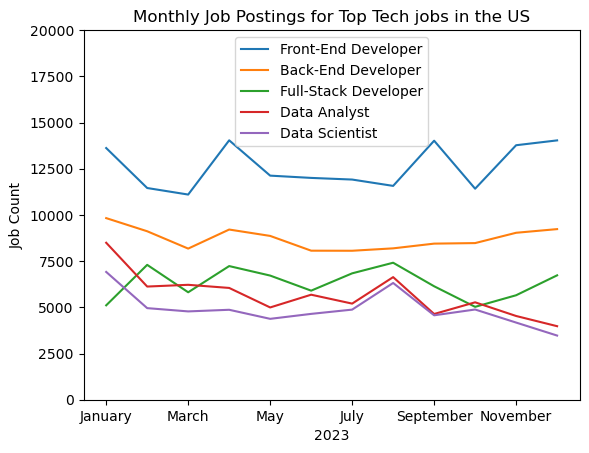

In [43]:
df_us_merged[top_5].plot(kind='line')
plt.title("Monthly Job Postings for Top Tech jobs in the US")
plt.xlabel("2023")
plt.ylabel("Job Count")
plt.ylim(0, 20000)
plt.legend()
plt.show()